In [1]:
try:
    from google.colab import drive  # pyright: ignore[reportMissingImports]
    drive.mount('/content/drive')
    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False
    print("Running locally; skipping Google Drive mount.")

Running locally; skipping Google Drive mount.


In [2]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [5]:
import os

dataset_path = (
    "/content/drive/MyDrive/Colab/cell_images/cell_images"
    if globals().get("IN_COLAB", False)
    else os.path.join(os.getcwd(), "cell_images")
)

In [6]:
import tensorflow as tf

IMG_SIZE = (64, 64)
BATCH_SIZE = 32
SEED = 123
TRAIN_SPLIT = 0.70
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

full_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

class_names = full_ds.class_names
num_batches = tf.data.experimental.cardinality(full_ds).numpy()
train_batches = int(num_batches * TRAIN_SPLIT)
val_batches = int(num_batches * VAL_SPLIT)
test_batches = num_batches - train_batches - val_batches

train_ds = full_ds.take(train_batches)
remaining_ds = full_ds.skip(train_batches)
val_ds = remaining_ds.take(val_batches)
test_ds = remaining_ds.skip(val_batches)

print(f"Classes: {class_names}")
print(f"Training batches: {train_batches}")
print(f"Validation batches: {val_batches}")
print(f"Test batches: {test_batches}")

Found 27558 files belonging to 2 classes.
Classes: ['Parasitized', 'Uninfected']
Training batches: 603
Validation batches: 129
Test batches: 130


In [7]:
for images, labels in train_ds.take(1):
    print(labels.numpy())

[0 1 1 0 0 1 0 0 1 1 1 0 1 1 0 0 1 1 0 1 1 1 1 0 0 1 0 0 0 0 1 0]


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [9]:
layers = tf.keras.layers
models = tf.keras.models

model = models.Sequential([
    tf.keras.Input(shape=(64,64,3)),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 76s 102ms/step - accuracy: 0.7908 - auc: 0.8961 - loss: 0.3964 - val_accuracy: 0.9532 - val_auc: 0.9827 - val_loss: 0.1593
Epoch 2/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 46s 76ms/step - accuracy: 0.9528 - auc: 0.9833 - loss: 0.1492 - val_accuracy: 0.9508 - val_auc: 0.9861 - val_loss: 0.1509
Epoch 3/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 56s 92ms/step - accuracy: 0.9558 - auc: 0.9860 - loss: 0.1362 - val_accuracy: 0.9593 - val_auc: 0.9861 - val_loss: 0.1396
Epoch 4/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 50s 83ms/step - accuracy: 0.9575 - auc: 0.9886 - loss: 0.1235 - val_accuracy: 0.9578 - val_auc: 0.9877 - val_loss: 0.1335
Epoch 5/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 51s 85ms/step - accuracy: 0.9600 - auc: 0.9899 - loss: 0.1173 - val_accuracy: 0.9595 - val_auc: 0.9881 - val_loss: 0.1317
Epoch 6/10
603/603 ━━━━━━━━━━━━━━━━━━━━ 50s 83ms/step - accuracy: 0.9610 - auc: 0.9911 - loss: 0.1103 - val_accuracy: 0.9581 - val_auc: 0.9865 - val_loss: 0.1405
Epoch 7/10
603/603 ━━━━━━━━

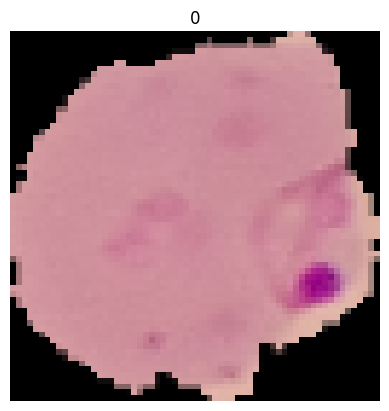

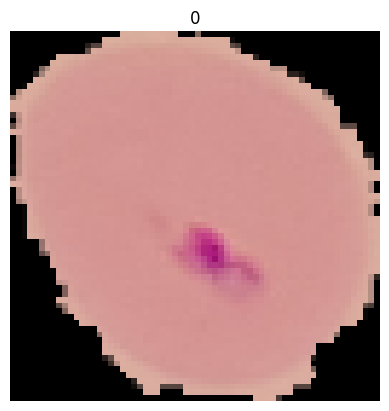

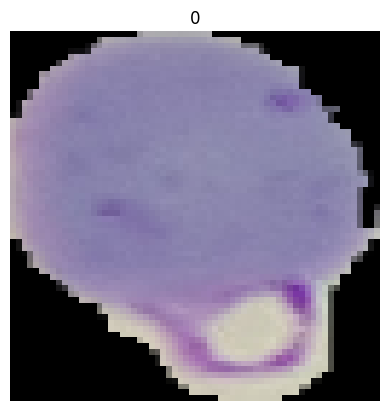

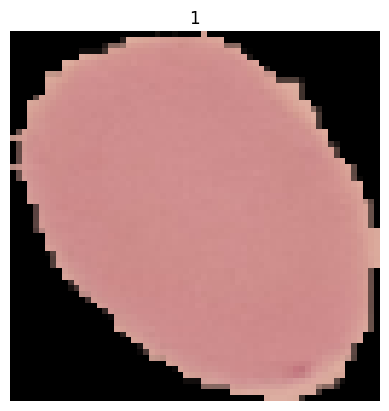

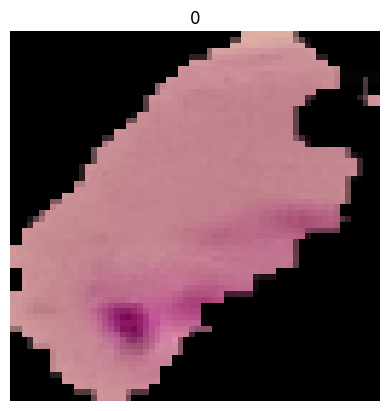

In [12]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    for i in range(5):
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(labels[i].numpy())
        plt.axis("off")
        plt.show()

In [13]:
model_path = (
    "/content/drive/MyDrive/malaria_model.keras"
    if globals().get("IN_COLAB", False)
    else "malaria_model.keras"
)

model.save(model_path)

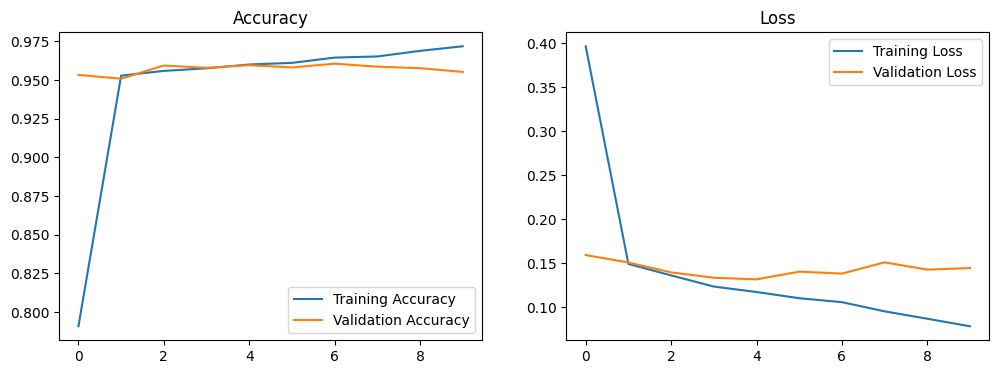

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [15]:
import tensorflow as tf

model_path = (
    "/content/drive/MyDrive/malaria_model.keras"
    if globals().get("IN_COLAB", False)
    else "malaria_model.keras"
)

model = tf.keras.models.load_model(model_path)

In [16]:
import os

if globals().get("IN_COLAB", False):
    parasitized_img = "/content/drive/MyDrive/Colab/cell_images/cell_images/Parasitized/C189P150ThinF_IMG_20151203_142224_cell_98.png"
    uninfected_img = "/content/drive/MyDrive/Colab/cell_images/cell_images/Uninfected/C223ThinF_IMG_20151112_104118_cell_228.png"
else:
    parasitized_img = os.path.join(dataset_path, "Parasitized", "C189P150ThinF_IMG_20151203_142224_cell_98.png")
    uninfected_img = os.path.join(dataset_path, "Uninfected", "C223ThinF_IMG_20151112_104118_cell_228.png")

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

def predict_image(img_path):
    img = load_img(img_path, target_size=IMG_SIZE)

    plt.imshow(img)
    plt.axis('off')
    plt.show()

    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prob_class_1 = model.predict(img_array, verbose=0)[0][0]
    predicted_index = int(prob_class_1 >= 0.5)
    confidence = prob_class_1 if predicted_index == 1 else 1 - prob_class_1

    print(f"Prediction: {class_names[predicted_index]} ({confidence:.4f} confidence)")

In [18]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

def predict_label(img_path):
    img = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    prob_class_1 = model.predict(img_array, verbose=0)[0][0]

    return int(prob_class_1 >= 0.5)

In [19]:
test_results = model.evaluate(test_ds, return_dict=True)

print("Final Test Set Results")
for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

print(f"Test Accuracy: {test_results['accuracy'] * 100:.2f}%")

130/130 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.9567 - auc: 0.9891 - loss: 0.1250
Final Test Set Results
accuracy: 0.9567
auc: 0.9891
loss: 0.1250
Test Accuracy: 95.67%


In [20]:
y_true = []
y_prob = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0).reshape(-1)
    y_prob.extend(probs)
    y_true.extend(labels.numpy())

y_true = np.array(y_true).astype(int)
y_pred = (np.array(y_prob) >= 0.5).astype(int)

cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=len(class_names)).numpy()

print("Confusion Matrix")
print("Rows = actual, columns = predicted")
print(f"Class order: {class_names}")
print(cm)
print()

for class_index, class_name in enumerate(class_names):
    tp = np.sum((y_true == class_index) & (y_pred == class_index))
    fp = np.sum((y_true != class_index) & (y_pred == class_index))
    fn = np.sum((y_true == class_index) & (y_pred != class_index))

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) else 0

    print(f"{class_name} precision: {precision:.4f}")
    print(f"{class_name} recall: {recall:.4f}")
    print(f"{class_name} F1-score: {f1_score:.4f}")
    print()

Confusion Matrix
Rows = actual, columns = predicted
Class order: ['Parasitized', 'Uninfected']
[[1910  127]
 [  52 2045]]

Parasitized precision: 0.9735
Parasitized recall: 0.9377
Parasitized F1-score: 0.9552

Uninfected precision: 0.9415
Uninfected recall: 0.9752
Uninfected F1-score: 0.9581



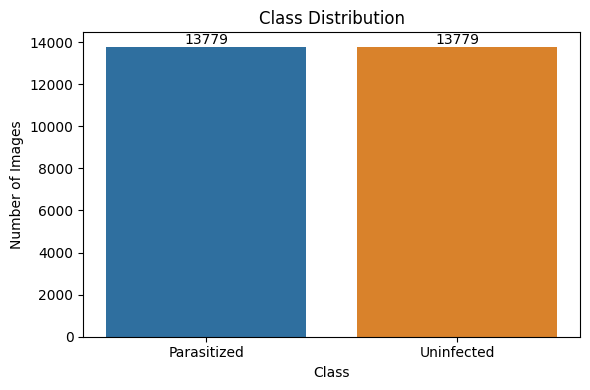

In [21]:
# Class distribution in the full dataset
class_counts = []

for class_name in class_names:
    class_dir = os.path.join(dataset_path, class_name)
    count = len([
        file_name for file_name in os.listdir(class_dir)
        if file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff'))
    ])
    class_counts.append(count)

plt.figure(figsize=(6, 4))
bars = plt.bar(class_names, class_counts, color=['#2f6f9f', '#d9822b'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')

for bar, count in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

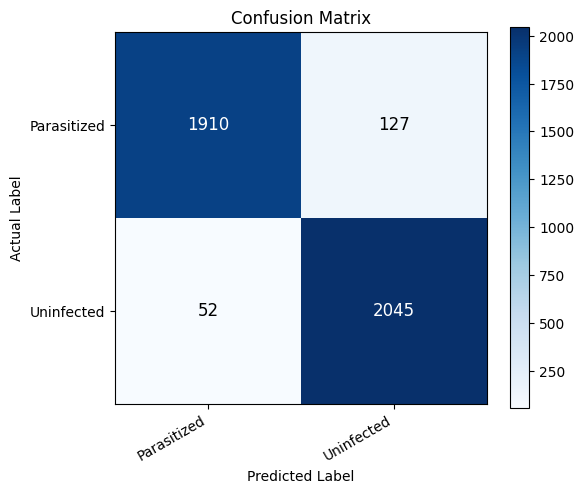

In [22]:
# Confusion matrix heatmap
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.xticks(range(len(class_names)), class_names, rotation=30, ha='right')
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()

threshold = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = 'white' if cm[i, j] > threshold else 'black'
        plt.text(j, i, cm[i, j], ha='center', va='center', color=color, fontsize=12)

plt.tight_layout()
plt.show()

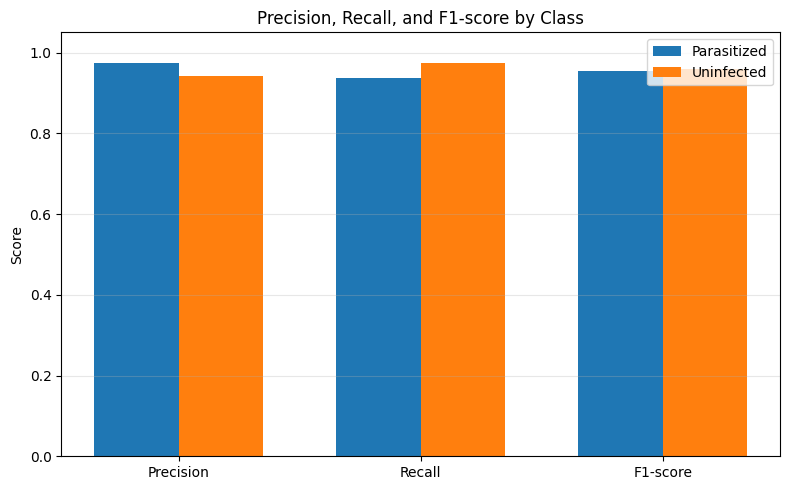

In [23]:
# Precision, recall, and F1-score bar chart
metric_names = ['Precision', 'Recall', 'F1-score']
class_metrics = []

for class_index, class_name in enumerate(class_names):
    tp = np.sum((y_true == class_index) & (y_pred == class_index))
    fp = np.sum((y_true != class_index) & (y_pred == class_index))
    fn = np.sum((y_true == class_index) & (y_pred != class_index))

    precision = tp / (tp + fp) if (tp + fp) else 0
    recall = tp / (tp + fn) if (tp + fn) else 0
    f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
    class_metrics.append([precision, recall, f1_score])

class_metrics = np.array(class_metrics)
x = np.arange(len(metric_names))
width = 0.35

plt.figure(figsize=(8, 5))
for class_index, class_name in enumerate(class_names):
    offset = (class_index - (len(class_names) - 1) / 2) * width
    plt.bar(x + offset, class_metrics[class_index], width, label=class_name)

plt.title('Precision, Recall, and F1-score by Class')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(x, metric_names)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

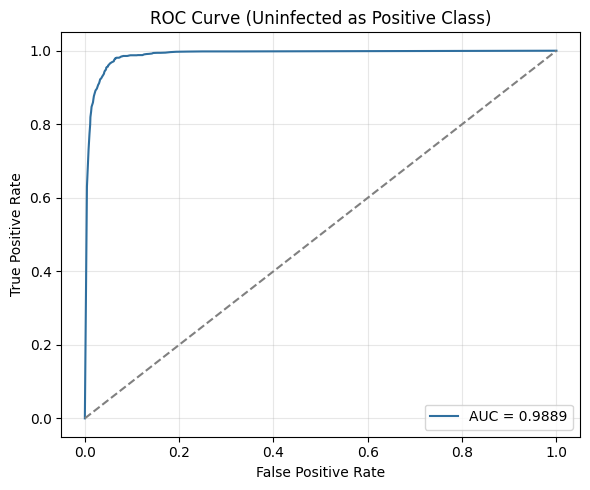

In [24]:
# ROC curve and AUC
positive_class = 1
scores = np.array(y_prob)
labels = (np.array(y_true) == positive_class).astype(int)

thresholds = np.linspace(1, 0, 101)
fpr_values = []
tpr_values = []

for threshold in thresholds:
    threshold_pred = (scores >= threshold).astype(int)

    tp = np.sum((labels == 1) & (threshold_pred == 1))
    fp = np.sum((labels == 0) & (threshold_pred == 1))
    tn = np.sum((labels == 0) & (threshold_pred == 0))
    fn = np.sum((labels == 1) & (threshold_pred == 0))

    tpr = tp / (tp + fn) if (tp + fn) else 0
    fpr = fp / (fp + tn) if (fp + tn) else 0
    tpr_values.append(tpr)
    fpr_values.append(fpr)

fpr_values = np.array(fpr_values)
tpr_values = np.array(tpr_values)
sort_order = np.argsort(fpr_values)
fpr_sorted = fpr_values[sort_order]
tpr_sorted = tpr_values[sort_order]

if hasattr(np, 'trapezoid'):
    roc_auc = np.trapezoid(tpr_sorted, fpr_sorted)
else:
    roc_auc = np.trapz(tpr_sorted, fpr_sorted)

plt.figure(figsize=(6, 5))
plt.plot(fpr_sorted, tpr_sorted, label=f'AUC = {roc_auc:.4f}', color='#2f6f9f')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title(f'ROC Curve ({class_names[positive_class]} as Positive Class)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

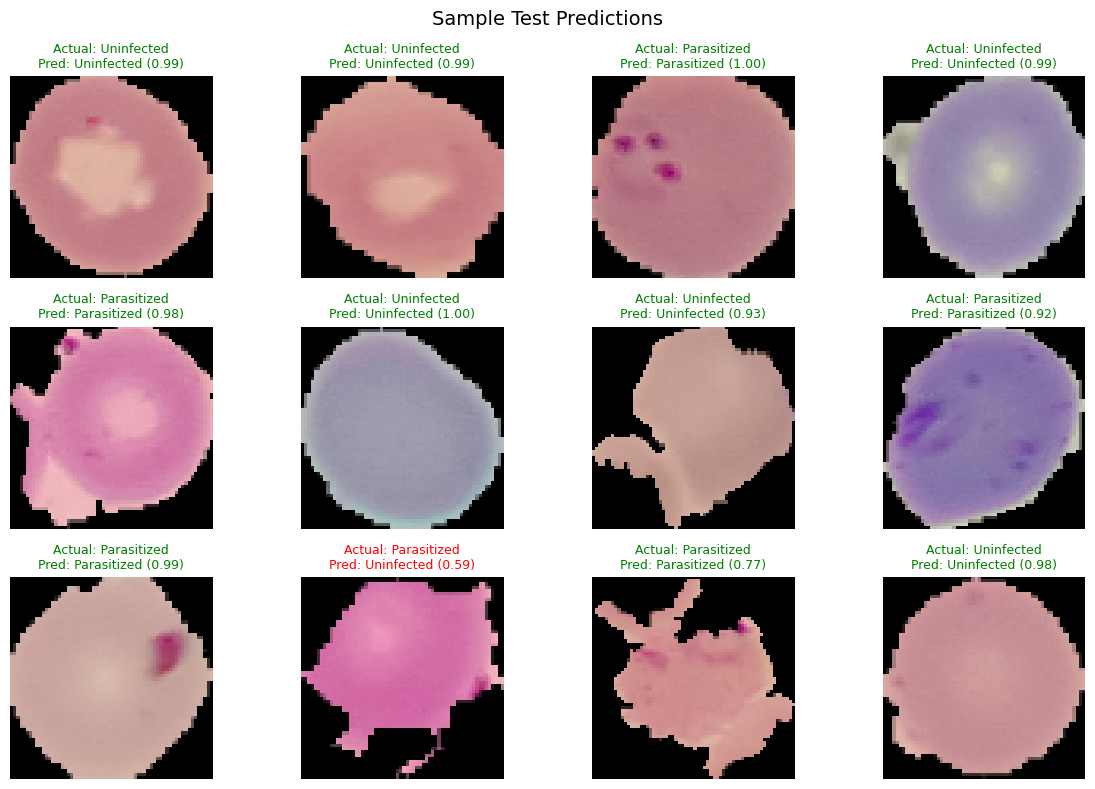

In [25]:
# Example predictions from the test set
plt.figure(figsize=(12, 8))
shown = 0
max_images = 12

for images, labels in test_ds.unbatch().take(max_images):
    image_batch = tf.expand_dims(images, axis=0)
    prob_class_1 = model.predict(image_batch, verbose=0)[0][0]
    predicted_index = int(prob_class_1 >= 0.5)
    confidence = prob_class_1 if predicted_index == 1 else 1 - prob_class_1
    actual_index = int(labels.numpy())

    plt.subplot(3, 4, shown + 1)
    plt.imshow(images.numpy().astype('uint8'))
    title_color = 'green' if predicted_index == actual_index else 'red'
    title_text = f"Actual: {class_names[actual_index]}\nPred: {class_names[predicted_index]} ({confidence:.2f})"
    plt.title(title_text, color=title_color, fontsize=9)
    plt.axis('off')
    shown += 1

plt.suptitle('Sample Test Predictions', fontsize=14)
plt.tight_layout()
plt.show()

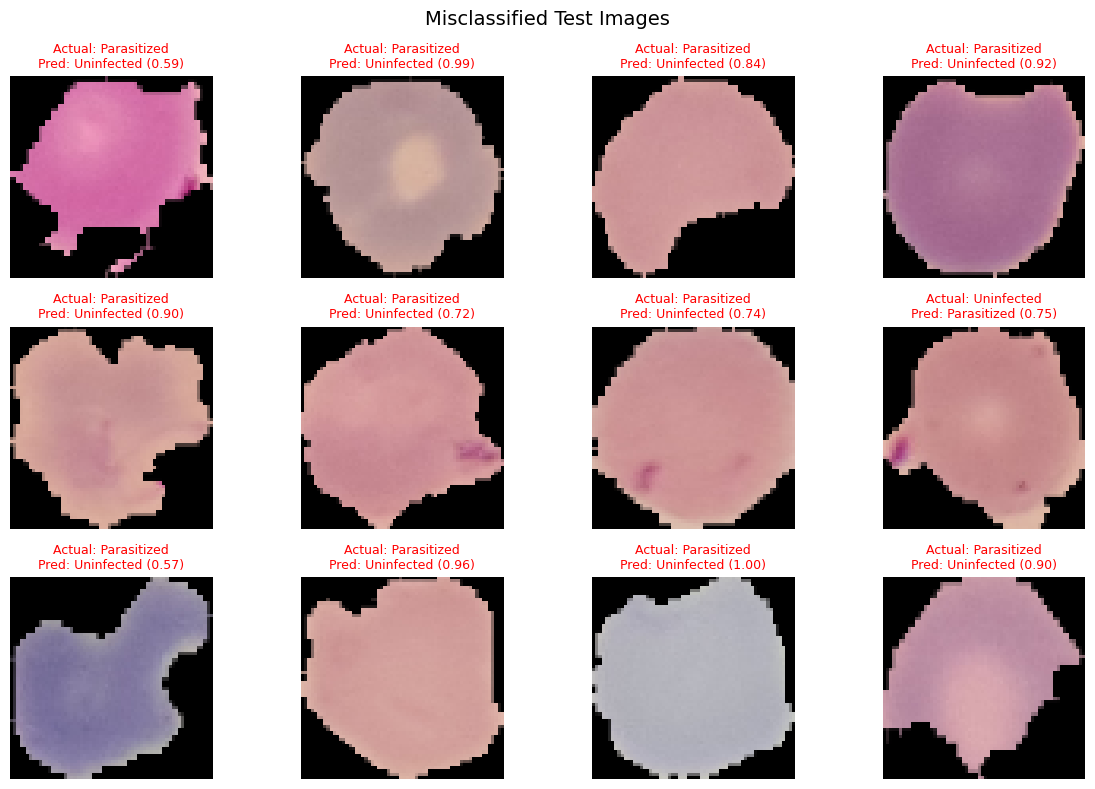

In [26]:
# Misclassified test images
misclassified_images = []
misclassified_actual = []
misclassified_pred = []
misclassified_conf = []
max_misclassified = 12

for images, labels in test_ds.unbatch():
    image_batch = tf.expand_dims(images, axis=0)
    prob_class_1 = model.predict(image_batch, verbose=0)[0][0]
    predicted_index = int(prob_class_1 >= 0.5)
    confidence = prob_class_1 if predicted_index == 1 else 1 - prob_class_1
    actual_index = int(labels.numpy())

    if predicted_index != actual_index:
        misclassified_images.append(images.numpy().astype('uint8'))
        misclassified_actual.append(actual_index)
        misclassified_pred.append(predicted_index)
        misclassified_conf.append(confidence)

    if len(misclassified_images) >= max_misclassified:
        break

if misclassified_images:
    plt.figure(figsize=(12, 8))
    for i, image in enumerate(misclassified_images):
        plt.subplot(3, 4, i + 1)
        plt.imshow(image)
        title_text = f"Actual: {class_names[misclassified_actual[i]]}\nPred: {class_names[misclassified_pred[i]]} ({misclassified_conf[i]:.2f})"
        plt.title(title_text, color='red', fontsize=9)
        plt.axis('off')

    plt.suptitle('Misclassified Test Images', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('No misclassified images found in the displayed test subset.')